<div style="margin: auto; width: fit-content; border: 1px solid #007acc; background-color: #e6f2ff; padding: 10px 20px; border-radius: 8px; text-align: center;">
  <h3 style="margin: 0;">🎯 Automatic Speech Recognition </h3>
    
</div>


## 🎙️ Speech-to-Text with Deep Learning: A Starter Notebook

This notebook provides a practical implementation of **automatic speech recognition (ASR)** using deep learning. The goal is to build a model that converts spoken audio into text using **spectrogram features** and a **DeepSpeech-like** architecture trained with **Connectionist Temporal Classification (CTC)** loss.

We extract audio features such as **log-Mel spectrograms** (with 80 features) and feed them into an RNN-based model, ultimately predicting character sequences that form the transcribed text. The output vocabulary is based on characters mapped using `StringLookup`, and decoding is performed using greedy decoding from the model outputs.

This notebook is a good starting point if you're interested in:

* Understanding the end-to-end process of speech-to-text.
* Experimenting with audio preprocessing, model building, training, and evaluation (using Word Error Rate).
* Learning how to work with TensorFlow/Keras and CTC loss in ASR systems.

### 📚 Reference for Further Learning

To better understand how ASR works conceptually and technically, this Medium article is an **excellent resource**:
👉 [Audio Deep Learning Made Simple: Automatic Speech Recognition (ASR), How it Works](https://medium.com/data-science/audio-deep-learning-made-simple-automatic-speech-recognition-asr-how-it-works-716cfce4c706)

It covers the intuition and architecture of speech recognition pipelines and how components like feature extraction, recurrent layers, and CTC decoding work together.


# Requirements

In [1]:
!pip install jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 63.6 MB/s eta 0:00:00


# Import Libraries

In [2]:
import os
import random
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
from wordcloud import WordCloud, STOPWORDS
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers
from jiwer import wer

import IPython.display as ipd
from IPython.display import Audio, HTML, display
from IPython import display

2025-06-08 14:23:26.924715: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749392607.161632      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749392607.229723      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# Constants

In [3]:
data_path = '/kaggle/input/the-lj-speech-dataset/LJSpeech-1.1'
wavs_path = data_path + '/wavs'
metadata_path = data_path + '/metadata.csv'

# LJSpeech Dataset Exploration

This notebook explores the LJSpeech dataset, available at https://keithito.com/LJ-Speech-Dataset/.

The dataset contains the following information for each audio sample:

* **ID:** The unique identifier corresponding to the `.wav` audio file.
* **Transcription:** The raw text transcription of the spoken words (UTF-8 encoded).
* **Normalized Transcription:** A processed version of the transcription where numbers, ordinals (e.g., "1st"), and monetary units (e.g., "$10") have been expanded into their full written forms.

## Initial Exploration

In [4]:
import pandas as pd

metadata_df = pd.read_csv(metadata_path, sep='|', header=None, quoting=3)

In [5]:
metadata_df.head()

,0,1,2
0,LJ001-0001,"Printing, in the only sense with which we are ...","Printing, in the only sense with which we are ..."
1,LJ001-0002,in being comparatively modern.,in being comparatively modern.
2,LJ001-0003,For although the Chinese took impressions from...,For although the Chinese took impressions from...
3,LJ001-0004,"produced the block books, which were the immed...","produced the block books, which were the immed..."
4,LJ001-0005,the invention of movable metal letters in the ...,the invention of movable metal letters in the ...


In [6]:
metadata_df.columns = ['file_name','transcription','normalized_transcription']
metadata_df = metadata_df[['file_name','normalized_transcription']]
metadata_df = metadata_df.sample(frac=1).reset_index(drop=True)
metadata_df.head()

,file_name,normalized_transcription
0,LJ004-0067,or to make him sleep in close contact with the...
1,LJ029-0083,"On November four, Sorrels told Behn he believe..."
2,LJ038-0059,that there was no one near Oswald who had a sh...
3,LJ015-0041,and the various discount houses would not adva...
4,LJ003-0068,the man guilty of a common assault found himse...


In [7]:
metadata_df.describe()

,file_name,normalized_transcription
count,13100,13100
unique,13100,13074
top,LJ007-0131,Report of the President's Commission on the As...
freq,1,12


In [8]:
metadata_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13100 entries, 0 to 13099
Data columns (total 2 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   file_name                 13100 non-null  object
 1   normalized_transcription  13100 non-null  object
dtypes: object(2)
memory usage: 204.8+ KB


## Audio Quality Exploration


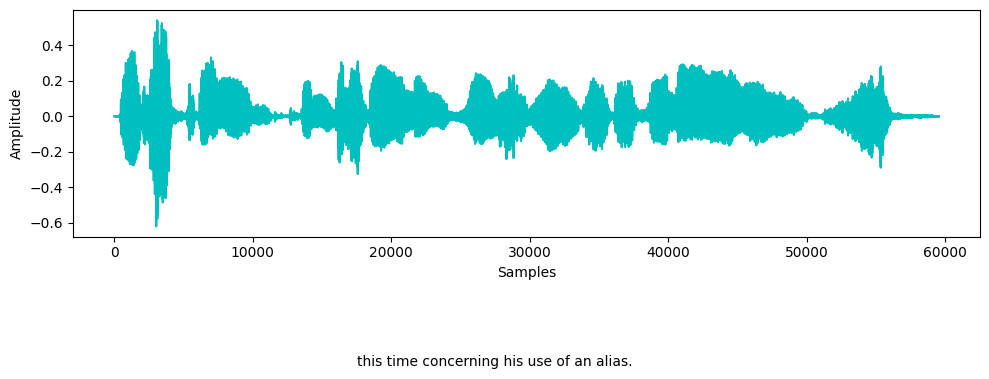

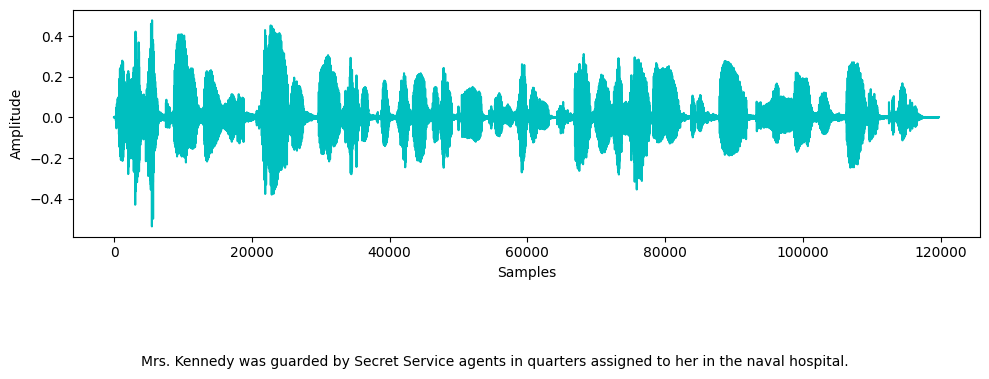

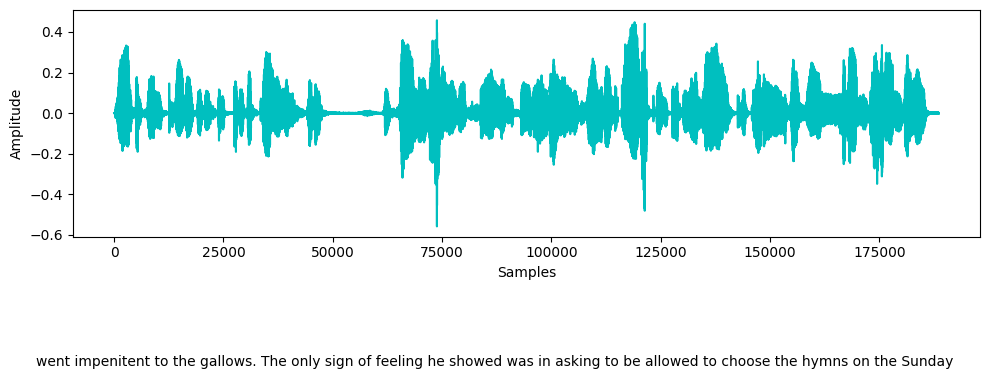

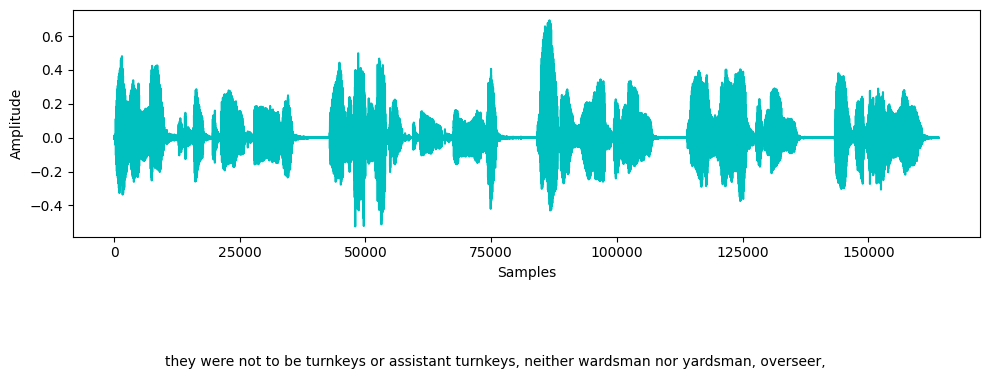

In [9]:
random.seed(42)
wav_files = [f for f in os.listdir(wavs_path) if f.endswith('.wav')]
random_wavs = random.sample(wav_files, 4)

# Clear any potential naming conflicts
if 'display' in globals():
    del display
if 'HTML' in globals():
    del HTML

# Use the module-qualified version
ipd.display(ipd.HTML("<style>.container { display: flex; flex-direction: column; }</style>"))

for i, wav in enumerate(random_wavs):
    wav_path = os.path.join(wavs_path, wav)
    y, sr = librosa.load(wav_path, sr=None)

    file_id = wav.split('.')[0]
    transcription = metadata_df[metadata_df['file_name'] == file_id]['normalized_transcription'].values[0]

    # Create container
    ipd.display(ipd.HTML(f"<div class='container' style='margin-bottom: 30px;'>"))

    # Display elements
    ipd.display(ipd.HTML(f"<h3>{wav}</h3>"))
    ipd.display(ipd.Audio(y, rate=sr))

    # Create plot
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(y, color='c')
    ax.set_xlabel("Samples")
    ax.set_ylabel("Amplitude")
    plt.figtext(0.5, -0.2, transcription, ha='center', va='top', fontsize=10, wrap=True)
    plt.tight_layout()
    ipd.display(fig)
    plt.close()
    ipd.display(ipd.HTML("</div>"))

## Check for Duplicates or Missing Data

In [10]:
len(os.listdir(wavs_path)) == len(metadata_df)

True

In [11]:
counter = 0
for file in os.listdir(wavs_path):
    if file.split('.wav')[0] not in metadata_df['file_name'].tolist():
      counter = counter + 1
print(counter)

0


In [12]:
metadata_df.isnull().sum()

file_name                   0
normalized_transcription    0
dtype: int64

In [13]:
metadata_df.duplicated().sum()

0

The dataset contains no duplicate records and is free of missing values.

## Audio Duration Statistics

In [14]:
durations = []
for fname in metadata_df['file_name']:
    audio_path = f'{wavs_path}/{fname}.wav'
    y, sr = librosa.load(audio_path, sr=None)
    durations.append(len(y) / sr)

metadata_df['duration_sec'] = durations
print(metadata_df['duration_sec'].describe())

count    13100.000000
mean         6.573823
std          2.185431
min          1.110068
25%          4.987800
50%          6.764127
75%          8.389524
max         10.096190
Name: duration_sec, dtype: float64


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


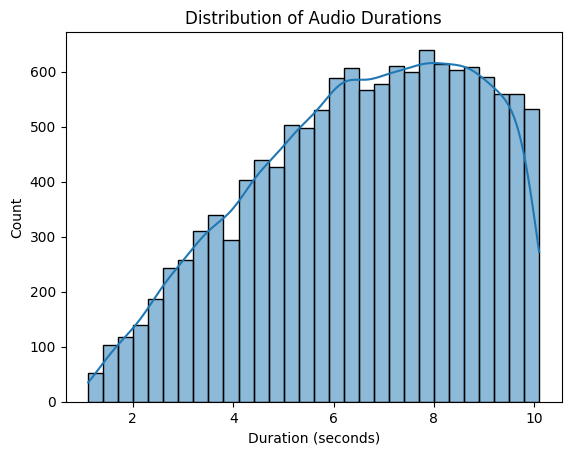

In [15]:
sns.histplot(metadata_df['duration_sec'], bins=30, kde=True)
plt.title("Distribution of Audio Durations")
plt.xlabel("Duration (seconds)")
plt.ylabel("Count")
plt.show()


The LJSpeech dataset exhibits a **negatively skewed (left-skewed) distribution** of audio durations, with most recordings concentrated between **6 and 10 seconds**, making them ideal for speech-to-text (STT) tasks. This range offers sufficient linguistic context for accurate transcription without excessive processing overhead. However, shorter audios (<6s) may lack context and lead to reduced accuracy, while longer audios (>10s) risk memory strain and context loss in models. To optimize processing, short clips can be padded and long clips segmented, ensuring consistent input for training and inference. Monitoring transcription accuracy across different durations helps detect weaknesses and guide preprocessing strategies, ultimately ensuring robust STT performance across the dataset.


## Text Analysis

In [16]:
np.random.seed(101)
metadata_df['normalized_transcription'][np.random.randint(0,10)]

'On November four, Sorrels told Behn he believed security difficulties at the Trade Mart could be overcome by special precautions.'

count    13100.000000
mean        16.986565
std          6.063484
min          1.000000
25%         13.000000
50%         17.000000
75%         21.000000
max         39.000000
Name: word_len, dtype: float64


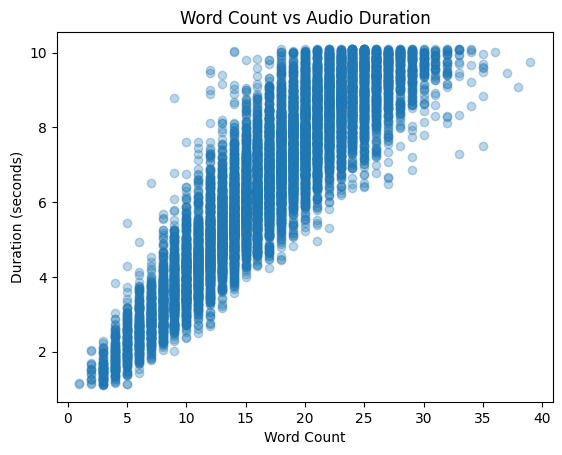

In [17]:
metadata_df['char_len'] = metadata_df['normalized_transcription'].str.len()
metadata_df['word_len'] = metadata_df['normalized_transcription'].str.split().apply(len)

print(metadata_df['word_len'].describe())

# Correlation plot
plt.scatter(metadata_df['word_len'], metadata_df['duration_sec'], alpha=0.3)
plt.xlabel("Word Count")
plt.ylabel("Duration (seconds)")
plt.title("Word Count vs Audio Duration")
plt.show()

The scatter plot shows a clear positive correlation between the number of words in a transcript and the duration of its corresponding audio clip. This indicates that longer utterances generally take more time to speak, which is expected in speech data. Most durations appear to be capped around 10 seconds. The strong linear trend supports the reliability of the dataset for training a speech-to-text model, though a few outliers may warrant further inspection. Overall, the plot confirms a consistent and usable alignment between audio and transcript lengths, which is essential for effective model training.










/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


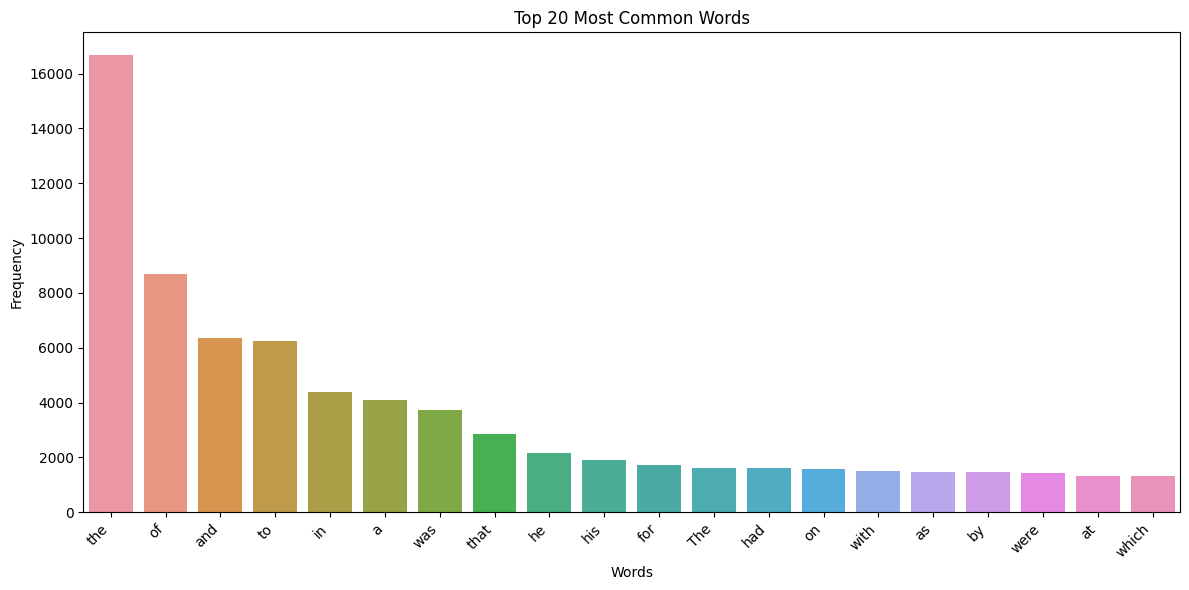

In [18]:
all_text = " ".join(metadata_df['normalized_transcription'].tolist())

# Split the text into words
words = all_text.split()

# Count word occurrences
word_counts = Counter(words)

# Most common 20 words
common_words = dict(word_counts.most_common(20))

# Create the bar plot
plt.figure(figsize=(12, 6)) 
sns.barplot(x=list(common_words.keys()), y=list(common_words.values()))
plt.title("Top 20 Most Common Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha='right')
plt.tight_layout() 
plt.show()

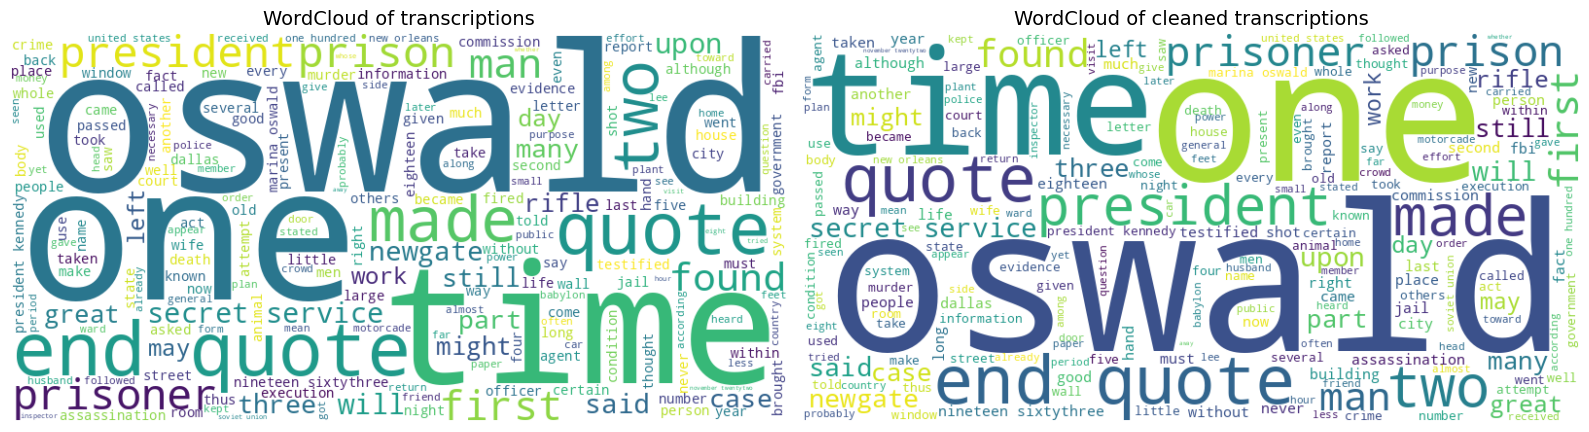

In [19]:
# Combine all transcriptions
text = ' '.join(metadata_df['normalized_transcription'].tolist())

# Basic cleaning
text = text.lower()                           # lowercase
text = re.sub(r'[^a-z\s]', '', text)          # remove punctuation and numbers
text = re.sub(r'\b\w{1,2}\b', '', text)       # remove short words (less than 3 letters)

# WordClouds: one without stopwords, one with
wordcloud0 = WordCloud(width=800, height=400, background_color='white').generate(text)
wordcloud1 = WordCloud(width=800, height=400, background_color='white', stopwords=set(STOPWORDS)).generate(text)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(wordcloud0, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title("WordCloud of transcriptions", fontsize=14)

axes[1].imshow(wordcloud1, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title("WordCloud of cleaned transcriptions", fontsize=14)

plt.tight_layout()
plt.show()

## Silence Detection / Voice Activity

In [20]:
def compute_silence_ratio(y, sr):
    non_silent_intervals = librosa.effects.split(y, top_db=20)
    total_speech_duration = sum([(e - s) / sr for s, e in non_silent_intervals])
    silence_ratio = 1 - (total_speech_duration / (len(y) / sr))
    return silence_ratio

# Apply the function and unpack (y, sr) from librosa.load
metadata_df['silence_ratio'] = metadata_df['file_name'].apply(
    lambda x: compute_silence_ratio(*librosa.load(f'{wavs_path}/{x}.wav', sr=None))
)

In [21]:
metadata_df['silence_ratio'].max()

0.48768342702330203

In [22]:
wav_path = os.path.join(wavs_path, metadata_df.iloc[metadata_df['silence_ratio'].idxmax()]['file_name'] + '.wav')
y, sr = librosa.load(wav_path, sr=None)
ipd.display(Audio(y, rate=sr))

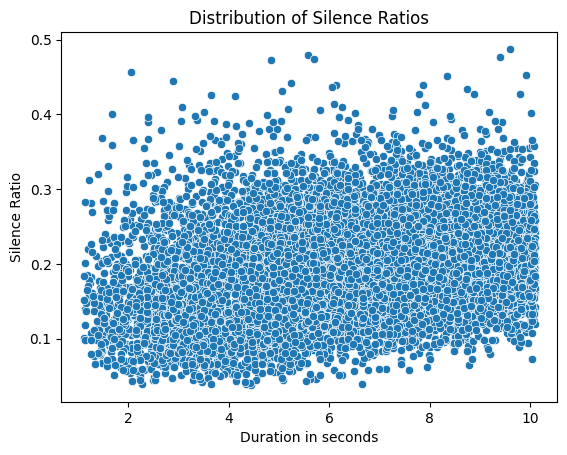

In [23]:
sns.scatterplot(data=metadata_df,y='silence_ratio',x='duration_sec')
plt.title("Distribution of Silence Ratios")
plt.ylabel("Silence Ratio")
plt.xlabel("Duration in seconds")
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


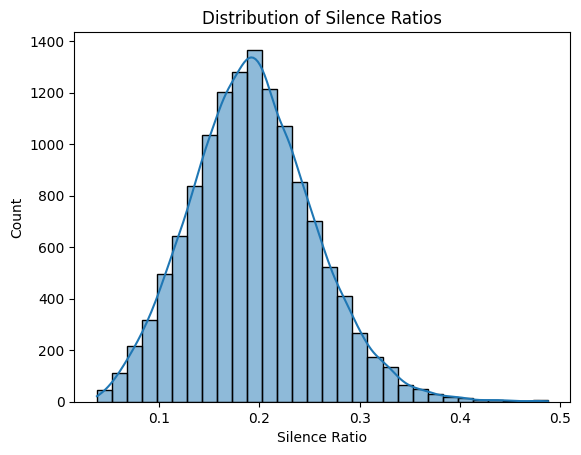

In [24]:
sns.histplot(metadata_df['silence_ratio'], bins=30, kde=True)
plt.title("Distribution of Silence Ratios")
plt.xlabel("Silence Ratio")
plt.ylabel("Count")
plt.show()

* Most data points cluster within a **silence ratio of 0.1 to 0.3**, indicating natural speech patterns with moderate pauses. A few outliers show extremely low (near 0) or high (>0.4) silence ratios, suggesting potential issues like overly trimmed audio or excessive background noise. However, upon reviewing the audio clip with the highest silence ratios, some of these cases appear to be **clean reading pauses** (e.g., deliberate breaks in narration or speech preparation), which are acceptable and do not necessarily reflect poor data quality.  



## Spectrogram/Signal Plots

In this notebook, we visualize and extract **time-frequency features** from raw audio signals to prepare them for training speech-to-text models. These features convert the 1D waveform into a richer, structured representation that captures **spectral** and **temporal** information relevant to human speech.

🎚️ 1. Short-Time Fourier Transform (STFT)

**Definition**:
STFT computes the Fourier Transform over **short overlapping windows** of the audio signal, capturing how frequency content evolves over time.

**Formula**:

$$
\text{STFT}\{x(t)\}(m, \omega) = \sum_{n=-\infty}^{\infty} x[n] \cdot w[n - m] \cdot e^{-j \omega n}
$$

* $x[n]$: audio signal
* $w[n - m]$: window function centered at frame $m$ (e.g., Hamming window)
* $\omega$: frequency bin (rad/sample)

STFT outputs a **complex spectrogram**; we typically use the **magnitude**:

$$
|X(m, \omega)| = \left| \text{STFT}(m, \omega) \right|
$$

![Diagram](https://www.mathworks.com/help/dsp/ref/stft_output.png)

**Why STFT**:

* Captures **localized time-frequency** patterns
* Ideal for audio visualization and analysis

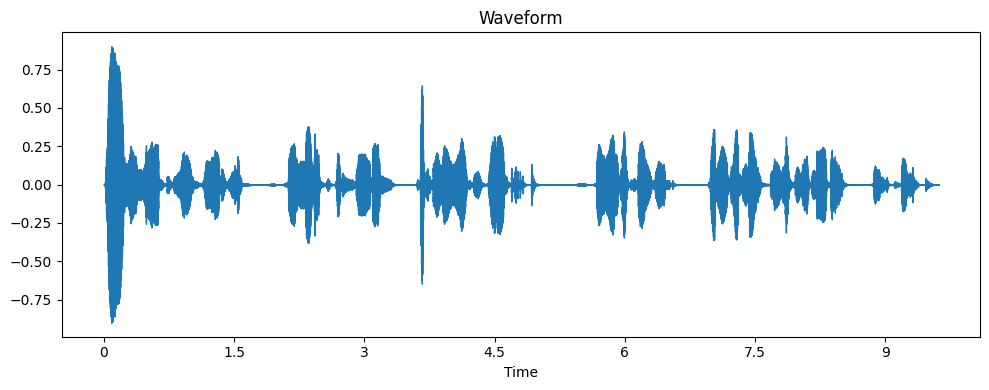

Transcription:

while he liked Youth House, he missed the freedom of doing what he wanted. He indicated that he did not miss his mother, end quote.


Text(0.5, 1.0, 'Log-frequency Spectrogram (STFT)')

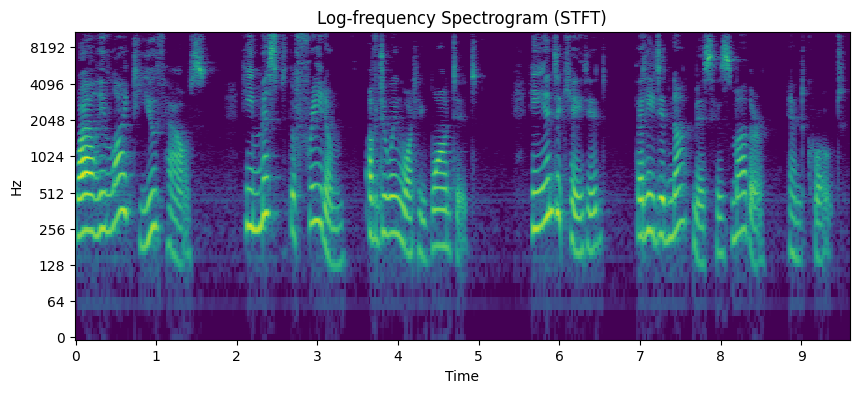

In [25]:
# Load audio with highest silence ratio
wav_path = os.path.join(wavs_path, metadata_df.iloc[metadata_df['silence_ratio'].idxmax()]['file_name'] + '.wav')
y, sr = librosa.load(wav_path, sr=None)

# Plot waveform
plt.figure(figsize=(10, 4))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform")
plt.tight_layout()
plt.show()

# Print transcription
print("Transcription:\n")
print(metadata_df.iloc[metadata_df['silence_ratio'].idxmax()]['normalized_transcription'])

# Compute Mel spectrogram
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
S_dB = librosa.power_to_db(S, ref=np.max)

# Compute STFT spectrogram
D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)

# Plot STFT and Mel spectrogram
plt.figure(figsize=(10,4))
img1 = librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log', cmap='viridis')
plt.title('Log-frequency Spectrogram (STFT)')

🔥 2. Mel Spectrogram

**Definition**:
The Mel Spectrogram maps the STFT magnitude spectrum to the **Mel scale**, a nonlinear scale approximating human pitch perception. Frequencies below 1 kHz are spaced linearly, and above that, logarithmically.


🔁 Step 1: Power Spectrum

$$
|X(k)|^2 \quad \text{for } k = 0 \ldots N-1
$$

* Where $N$ is the number of FFT bins.


🪞 Step 2: Apply Mel Filterbank

$$
S_{\text{mel}}(m) = \sum_{k=0}^{N-1} |X(k)|^2 \cdot H_m(k)
$$

* $S_{\text{mel}}(m)$: Mel energy in bin $m$
* $H_m(k)$: **Mel filterbank**, triangular filter weighting the contribution of frequency bin $k$ to Mel bin $m$


 🎵 Mel Filter Formula $H_m(k)$:

$$
H_m(k) =
\begin{cases}
0, & f[k] < f_{m-1} \text{ or } f[k] > f_{m+1} \\
\frac{f[k] - f_{m-1}}{f_m - f_{m-1}}, & f_{m-1} \leq f[k] \leq f_m \\
\frac{f_{m+1} - f[k]}{f_{m+1} - f_m}, & f_m \leq f[k] \leq f_{m+1}
\end{cases}
$$

* $f[k]$: Frequency corresponding to FFT bin $k$
* $f_{m-1}, f_m, f_{m+1}$: Mel-scaled filter boundaries
* The filters are **overlapping triangles** summing to 1 across frequency bins.


🔊 Step 3: Convert to Log Scale

$$
\text{Log-Mel}(m) = \log \left(S_{\text{mel}}(m) + \varepsilon \right)
$$

* $\varepsilon$: small constant to avoid $\log(0)$

**Why Log-Mel?**

* Mimics the **logarithmic nature of human loudness perception**
* Works better as input to neural networks due to **dynamic range compression**


Text(0.5, 1.0, 'Mel Spectrogram')

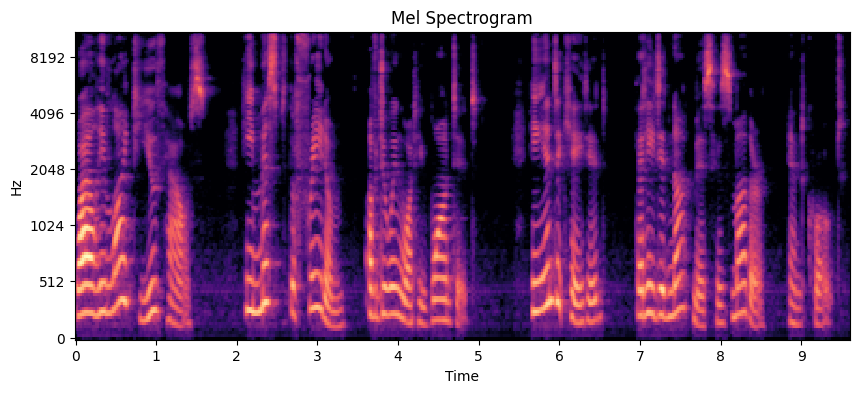

In [26]:
plt.figure(figsize=(10,4))
img2 = librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel', cmap='magma')
plt.title('Mel Spectrogram')

🧠 3. MFCC (Mel-Frequency Cepstral Coefficients)

**Definition**:
Applies a **Discrete Cosine Transform (DCT)** to the log-Mel spectrum to **decorrelate** features and compress information into a small set of **cepstral coefficients**.

**Formula**:

$$
\text{MFCC}_n = \sum_{m=1}^{M} \log \left(S_{\text{mel}}(m)\right) \cdot \cos \left[ \frac{\pi n}{M} (m - 0.5) \right]
$$

* $M$: number of Mel bins
* $n$: index of the cepstral coefficient (typically 13 retained)

**Why MFCC?**

* Used in traditional ASR systems (e.g., HMM-GMM)
* Reduces dimensionality, highlights **broad spectral shape**
* Less effective for deep learning than full log-Mel features

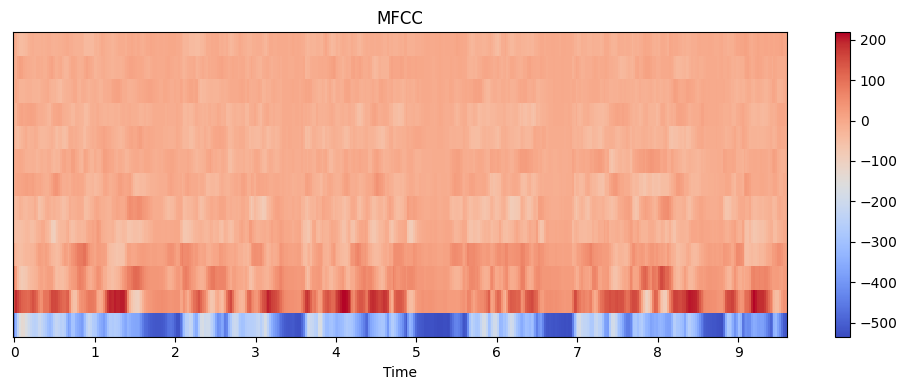

In [27]:
# Compute and plot MFCC
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
plt.figure(figsize=(10, 4))
librosa.display.specshow(mfccs, x_axis='time', sr=sr, cmap='coolwarm')
plt.colorbar()
plt.title('MFCC')
plt.tight_layout()
plt.show()

* On both graphs (Mel and STFT) distinct vertical bright patterns correspond to pronounced phonemes or syllables. Regular vertical dark bands indicate pauses or silences, particularly noticeable after the words “Youth House”, “wanted”, and “mother”. These silences can be leveraged to segment speech into phrases or prosodic units. The repetition of patterns between 100 Hz and 3000 Hz reflects the vocal formants characteristic of speech, allowing for the identification of key words such as “freedom”, “indicated”, or “liked”. The spectral analysis thus highlights not only the presence of spoken words but also the temporal structure of the speech, which is crucial for accurate automatic transcription.
* The MFCC plot displays a clean, continuous signal over time (0–9 units), indicating high-quality audio without clipping or prolonged silences. The lower-order coefficients (bottom rows) exhibit strong energy and variability, typical of active speech, while higher-order coefficients (top rows) remain stable, capturing finer spectral details. The consistent distribution of variations suggests a steady speech rate. Phoneme diversity is evident through dynamic coefficient changes, implying varied articulation. However, the wide dynamic range (e.g., values from -500 to 200) highlights the need for MFCC normalization to optimize STT model performance. Overall, the graph reflects clear, articulate speech with minimal noise—a robust input for transcription.

# Data Preprocssing

✅ Why This ***character-level encoding system*** is Needed in Speech-To-Text:
* Your model outputs sequences of integers, not letters.

* You need consistent, reversible mappings between characters and IDs.

* Allows the model to learn a language representation at the character level, which is more flexible than word-level when data is limited or noisy.

In [28]:
# The set of characters accepted in the transcription
characters = [x for x in "abcdefghijklmnopqrstuvwxyz'?! "]

# Mapping characters to integers
char_to_num = keras.layers.StringLookup(vocabulary=characters, oov_token="")

# Mapping integers back to original characters
num_to_char = keras.layers.StringLookup(
    vocabulary=char_to_num.get_vocabulary(), oov_token="", invert=True
)

# Affichage du vocabulaire
print(
    f"The vocabulary is: {char_to_num.get_vocabulary()} "
    f"(size = {char_to_num.vocabulary_size()})"
)

The vocabulary is: ['', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', "'", '?', '!', ' '] (size = 31)


I0000 00:00:1749392866.504922      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In audio data processing, we will be using **log-Mel spectrograms** because they:

* Align with human auditory perception
* Emphasize speech-relevant frequencies (0–8 kHz)
* Are **robust**, dense, and optimized for **modern neural STT architectures**

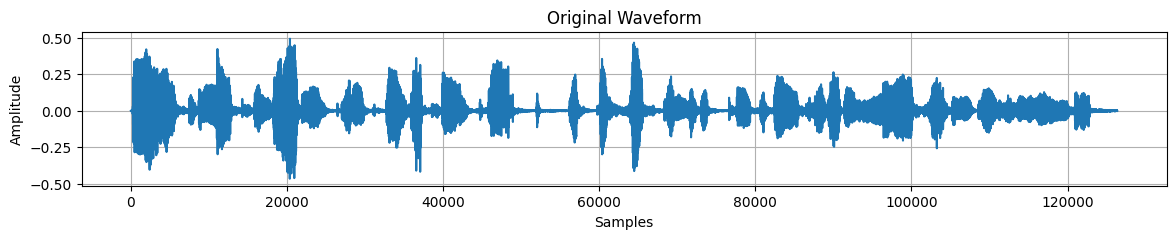

In [29]:
# Constants
frame_length = 256
frame_step = 168
fft_length = 384
num_mel_bins = 80
lower_freq = 80.0
upper_freq = 7600.0

# Step 1: Load audio
metadata_df["file_path"] = metadata_df["file_name"].apply(lambda name: os.path.join(wavs_path, name + ".wav"))
file_path = metadata_df['file_path'][0]
label_text = metadata_df['normalized_transcription'][0]

file = tf.io.read_file(file_path)
audio, sample_rate = tf.audio.decode_wav(file)
audio = tf.squeeze(audio, axis=-1)

# Step 2: Plot waveform
plt.figure(figsize=(14, 2))
plt.plot(audio.numpy())
plt.title("Original Waveform")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

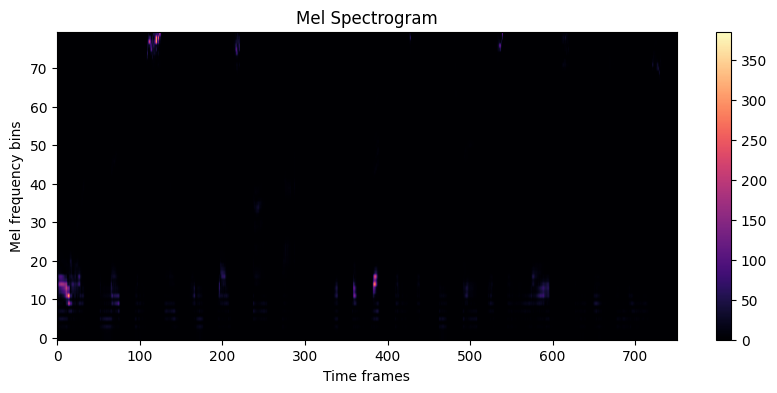

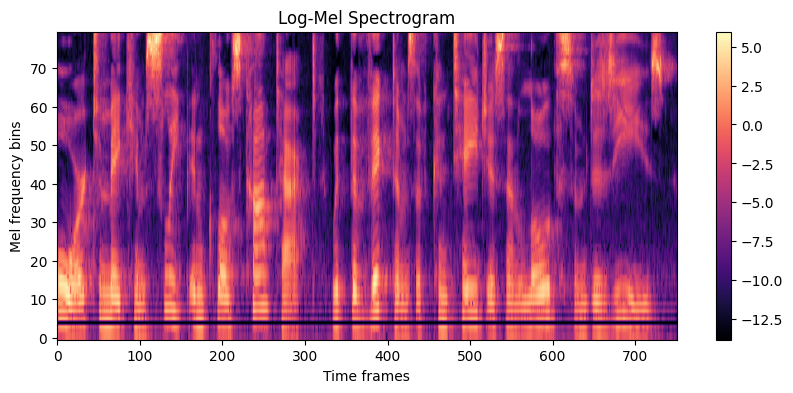

In [30]:
# Step 3: STFT
stft = tf.signal.stft(audio, frame_length=frame_length, frame_step=frame_step, fft_length=fft_length)

magnitude_spectrogram = tf.abs(stft)

# Number of spectrogram bins for the mel weight matrix
num_spectrogram_bins = fft_length // 2 + 1

# Step 4: Apply Mel filterbanks
linear_to_mel_weight_matrix = tf.signal.linear_to_mel_weight_matrix(
    num_mel_bins=num_mel_bins,
    num_spectrogram_bins=num_spectrogram_bins,
    sample_rate=tf.cast(sample_rate, tf.float32),
    lower_edge_hertz=lower_freq,
    upper_edge_hertz=upper_freq,
)

# Optionally use power spectrogram instead of magnitude
power_spectrogram = tf.square(magnitude_spectrogram)

mel_spectrogram = tf.matmul(power_spectrogram, linear_to_mel_weight_matrix)

# Plot Mel spectrogram
plt.figure(figsize=(10, 4))
plt.imshow(tf.transpose(mel_spectrogram).numpy(), aspect="auto", origin="lower", cmap="magma")
plt.colorbar()
plt.title("Mel Spectrogram")
plt.xlabel("Time frames")
plt.ylabel("Mel frequency bins")
plt.show()

# Step 5: Log scaling (dB-like)
log_mel_spectrogram = tf.math.log(mel_spectrogram + 1e-6)

# Step 6: Plot Log-Mel spectrogram
plt.figure(figsize=(10, 4))
plt.imshow(tf.transpose(log_mel_spectrogram).numpy(), aspect="auto", origin="lower", cmap="magma")
plt.colorbar()
plt.title("Log-Mel Spectrogram")
plt.xlabel("Time frames")
plt.ylabel("Mel frequency bins")
plt.show()

In [31]:
# Constants
frame_length = 256
frame_step = 168
fft_length = 384
num_mel_bins = 80  # Adjust based on your model
lower_freq = 80.0
upper_freq = 7600.0

def encode_single_sample(wav_file,label):

    file = tf.io.read_file(wav_file)
    audio, sample_rate = tf.audio.decode_wav(file)
    audio = tf.squeeze(audio, axis=-1)

    # Step 3: STFT
    stft = tf.signal.stft(audio, frame_length=frame_length, frame_step=frame_step, fft_length=fft_length)

    magnitude_spectrogram = tf.abs(stft)

    # Number of spectrogram bins for the mel weight matrix
    num_spectrogram_bins = fft_length // 2 + 1

    # Step 4: Apply Mel filterbanks
    linear_to_mel_weight_matrix = tf.signal.linear_to_mel_weight_matrix(
        num_mel_bins=num_mel_bins,
        num_spectrogram_bins=num_spectrogram_bins,
        sample_rate=tf.cast(sample_rate, tf.float32),
        lower_edge_hertz=lower_freq,
        upper_edge_hertz=upper_freq,
    )

    # Optionally use power spectrogram instead of magnitude
    power_spectrogram = tf.square(magnitude_spectrogram)

    mel_spectrogram = tf.matmul(power_spectrogram, linear_to_mel_weight_matrix)

    # Step 5: Log scaling (dB-like)
    log_mel_spectrogram = tf.math.log(mel_spectrogram + 1e-6)

    # Step 6:  Process the label (convert to lowercase)
    label = tf.strings.lower(label)

    # Step 7: Split label into characters
    label = tf.strings.unicode_split(label, input_encoding='UTF-8')

    # Step 8: Map characters to integers
    label = char_to_num(label)

    # Step 9: Return the spectrogram and the label
    return log_mel_spectrogram, label

## Data Splitting

In [32]:
split = int(len(metadata_df) * 0.90)
df_train = metadata_df[:split]
df_val = metadata_df[split:]
print(f"Size of the training set: {len(df_train)}")
print(f"Size of the testing set: {len(df_val)}")

Size of the training set: 11790
Size of the testing set: 1310


## Dataset Preparation

In [33]:
batch_size = 32

# Define the training dataset
train_dataset = tf.data.Dataset.from_tensor_slices(
    (list(df_train["file_path"]), list(df_train["normalized_transcription"]))
)

train_dataset = (
    train_dataset.map(encode_single_sample, num_parallel_calls=tf.data.AUTOTUNE)
    .padded_batch(batch_size)
    .prefetch(buffer_size=tf.data.AUTOTUNE)
)

# Define the validation dataset
validation_dataset = tf.data.Dataset.from_tensor_slices(
    (list(df_val["file_path"]), list(df_val["normalized_transcription"]))
)

validation_dataset = (
    validation_dataset.map(encode_single_sample, num_parallel_calls=tf.data.AUTOTUNE)
    .padded_batch(batch_size)
    .prefetch(buffer_size=tf.data.AUTOTUNE)
)

# Modeling

## Loss function

It allows training on unaligned input-output pairs by learning all possible alignments between audio frames and target transcriptions. It handles variable-length sequences and repeated characters using a special **blank token**, enabling efficient and flexible sequence modeling without the need for frame-level labeling.

The model, trained with CTC loss, learns to assign higher probabilities to the most likely valid alignment paths that collapse to the correct transcription — effectively focusing its predictions on the best paths.

Here’s a [Medium article](https://voidful.medium.com/understanding-ctc-loss-for-speech-recognition-a16a3ef4da92) that explains the advantages of using the CTC loss function.

The CTC (Connectionist Temporal Classification) Loss is defined as:

$$
\mathcal{L}_{\text{CTC}} = - \log \sum_{\pi \in \mathcal{B}^{-1}(y)} P(\pi | x)
$$

Where:
- \( x \): input sequence (logits or probabilities over time)
- \( y \): target label sequence (e.g., characters or words)
- \( $\pi$ \): alignment path (including blanks)
- \( $\mathcal{B}$ \): collapse function that removes repeated characters and blanks
- \( $\mathcal{B}^{-1}(y)$ \): all valid alignments that collapse to \( y \)
- \( P($\pi$ | x) \): probability of the alignment path \( $\pi$ \) given the input

In TensorFlow/Keras, this is computed as:

$$
\text{CTCLoss} = \text{keras.backend.ctc\_batch\_cost}(y_{\text{true}}, y_{\text{pred}}, \text{input\_length}, \text{label\_length})
$$


In [34]:
def CTCLoss(y_true, y_pred):
    # Compute the training-time loss value
    batch_len = tf.cast(tf.shape(y_true)[0], dtype="int64")
    input_length = tf.cast(tf.shape(y_pred)[1], dtype="int64")
    label_length = tf.cast(tf.shape(y_true)[1], dtype="int64")

    input_length = input_length * tf.ones(shape=(batch_len, 1), dtype="int64")
    label_length = label_length * tf.ones(shape=(batch_len, 1), dtype="int64")

    loss = keras.backend.ctc_batch_cost(y_true, y_pred, input_length, label_length)
    return loss

## Model Architecture

### 🧠 DeepSpeech2-Inspired Model Architecture
This model is an **end-to-end** architecture for automatic speech recognition, inspired by **DeepSpeech2**. It takes **audio spectrograms** as input and outputs a sequence of **character probabilities** at each time step, without requiring any prior alignment between the audio and the text, thanks to the **CTC (Connectionist Temporal Classification)** algorithm which will be explains later in the notebook.

### ⚙️ Model Architecture

* 🔷 **Convolutional Block (CNN)**
  Two 2D convolutional layers with **Batch Normalization** and **ReLU** are used to extract meaningful local representations from the spectrograms.
  These layers act as **feature extractors** from the audio input.

* 🔁 **Recurrent Block (Bi-GRU)**
  The extracted features are then transformed into temporal sequences and processed by multiple **Bidirectional GRU (Gated Recurrent Unit)** layers.
  These layers learn the temporal dependencies of the audio in both directions (past and future).

* 🔡 **Linear Layer + Softmax**
  A dense layer followed by a **softmax** layer produces the **character probabilities** at each time step.

* 🧩 **CTC Loss Function**
  Used to train the model without exact alignment between audio and text. It allows mapping a variable-length audio sequence to a character sequence.

In [35]:
def build_model(input_dim, output_dim, rnn_layers=5, rnn_units=128):
    """Model similar to DeepSpeech2."""

    # Model input
    input_spectrogram = layers.Input((None, input_dim), name="input")

    # Expand the dimension to use 2D CNN
    x = layers.Reshape((-1, input_dim, 1), name="expand_dim")(input_spectrogram)

    # Convolution layer 1
    x = layers.Conv2D(
        filters=32,
        kernel_size=(11, 41),
        strides=(2, 2),
        padding="same",
        use_bias=False,
        name="conv_1",
    )(x)
    x = layers.BatchNormalization(name="conv_1_bn")(x)
    x = layers.ReLU(name="conv_1_relu")(x)

    # Convolution layer 2
    x = layers.Conv2D(
        filters=32,
        kernel_size=(11, 21),
        strides=(1, 2),
        padding="same",
        use_bias=False,
        name="conv_2",
    )(x)
    x = layers.BatchNormalization(name="conv_2_bn")(x)
    x = layers.ReLU(name="conv_2_relu")(x)

    # Reshape the result to feed into RNN layers
    x = layers.Reshape((-1, x.shape[-2] * x.shape[-1]))(x)

    # RNN layers
    for i in range(1, rnn_layers + 1):
        recurrent = layers.GRU(
            units=rnn_units,
            activation="tanh",
            recurrent_activation="sigmoid",
            use_bias=True,
            return_sequences=True,
            reset_after=True,
            name=f"gru_{i}",
        )
        x = layers.Bidirectional(
            recurrent, name=f"bidirectional_{i}", merge_mode="concat"
        )(x)

        if i < rnn_layers:
            x = layers.Dropout(rate=0.5, name=f"dropout_{i}")(x)

    # Dense layer
    x = layers.Dense(units=rnn_units * 2, name="dense_1")(x)
    x = layers.ReLU(name="dense_1_relu")(x)
    x = layers.Dropout(rate=0.5, name="dense_1_dropout")(x)

    # Classification layer
    output = layers.Dense(units=output_dim + 1, activation="softmax", name="output")(x)

    # Build the model
    model = models.Model(input_spectrogram, output, name="DeepSpeech2")

    # Optimizer
    opt = optimizers.Adam(learning_rate=1e-4)

    # Compile the model
    model.compile(optimizer=opt, loss=CTCLoss)

    return model

In [36]:
model = build_model(
   input_dim = 80,
   output_dim = char_to_num.vocabulary_size(),
   rnn_units = 512,
)

model.summary(line_length=110)

Model: "DeepSpeech2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                   ┃ Output Shape                        ┃             Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)                             │ (None, None, 80)                    │                   0 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ expand_dim (Reshape)                           │ (None, None, 80, 1)                 │                   0 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv_1 (Conv2D)                                │ (None, None, 40, 32)                │              14,432 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv_1_bn (BatchNormalization)                 │ (None, None, 40, 32)                │                 128 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv_1_relu (ReLU)                             │ (None, None, 40, 32)                │                   0 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv_2 (Conv2D)                                │ (None, None, 20, 32)                │             236,544 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv_2_bn (BatchNormalization)                 │ (None, None, 20, 32)                │                 128 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv_2_relu (ReLU)                             │ (None, None, 20, 32)                │                   0 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ reshape (Reshape)                              │ (None, None, 640)                   │                   0 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ bidirectional_1 (Bidirectional)                │ (None, None, 1024)                  │           3,545,088 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ dropout_1 (Dropout)                            │ (None, None, 1024)                  │                   0 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ bidirectional_2 (Bidirectional)                │ (None, None, 1024)                  │           4,724,736 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ dropout_2 (Dropout)                            │ (None, None, 1024)                  │                   0 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ bidirectional_3 (Bidirectional)                │ (None, None, 1024)                  │           4,724,736 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ dropout_3 (Dropout)                            │ (None, None, 1024)                  │                   0 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ bidirectional_4 (Bidirectional)                │ (None, None, 1024)                  │           4,724,736 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ dropout_4 (Dropout)                            │ (None, None, 1024)                  │                   0 │
├───

 Total params: 23,777,664 (90.70 MB)

 Trainable params: 23,777,536 (90.70 MB)

 Non-trainable params: 128 (512.00 B)

### A utility function to decode the output of the network

In [37]:
def decode_batch_predictions(pred):
    input_len = np.ones(pred.shape[0]) * pred.shape[1]
    # Use greedy search. For complex tasks, you can use beam search
    results = keras.backend.ctc_decode(pred, input_length=input_len, greedy=True)[0][0]
    # Iterate over the results and get back the text
    output_text = []
    for result in results:
        result = tf.strings.reduce_join(num_to_char(result)).numpy().decode("utf-8")
        output_text.append(result)
    return output_text

### A callback class to output a few transcriptions during training

In [38]:
class CallbackEval(keras.callbacks.Callback):
    """Displays a batch of outputs after every epoch."""

    def __init__(self, dataset):
        super().__init__()
        self.dataset = dataset

    def on_epoch_end(self, epoch: int, logs=None):
        predictions = []
        targets = []

        for batch in self.dataset:
            X, y = batch
            batch_predictions = model.predict(X)
            batch_predictions = decode_batch_predictions(batch_predictions)
            predictions.extend(batch_predictions)

            for label in y:
                label = tf.strings.reduce_join(num_to_char(label)).numpy().decode("utf-8")
                targets.append(label)

        wer_score = wer(targets, predictions)
        if logs is not None:
            logs["wer"] = wer_score
        print("-" * 100)
        print(f"Word Error Rate: {wer_score:.4f}")
        print("-" * 100)

        for i in np.random.randint(0, len(predictions), 2):
            print(f"Target     : {targets[i]}")
            print(f"Prediction : {predictions[i]}")
            print("." * 100)

### Model setup for training

In [39]:
# Define the number of epochs
epochs = 70

# Callback to check transcription on the validation set
validation_callback = CallbackEval(validation_dataset)

# Callback to apply early stopping
early_stopping = keras.callbacks.EarlyStopping(
    monitor='loss',       
    patience=5,          
    restore_best_weights=True  
)

# Callback to save the best model checkpoint
model_checkpoint = keras.callbacks.ModelCheckpoint(
    filepath='best_model.keras',       
    monitor='wer',             
    save_best_only=True,            
    save_weights_only=False,        
    mode='min',                     
    verbose=1                       
)

## Model Training

In [40]:
# Train the model
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=epochs,
    callbacks=[early_stopping,validation_callback,model_checkpoint],
)

Epoch 1/70


I0000 00:00:1749392889.558856      75 cuda_dnn.cc:529] Loaded cuDNN version 90300


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 440

## Model Saving

In [41]:
model.save("final_model.keras")

## Performance Monitoring

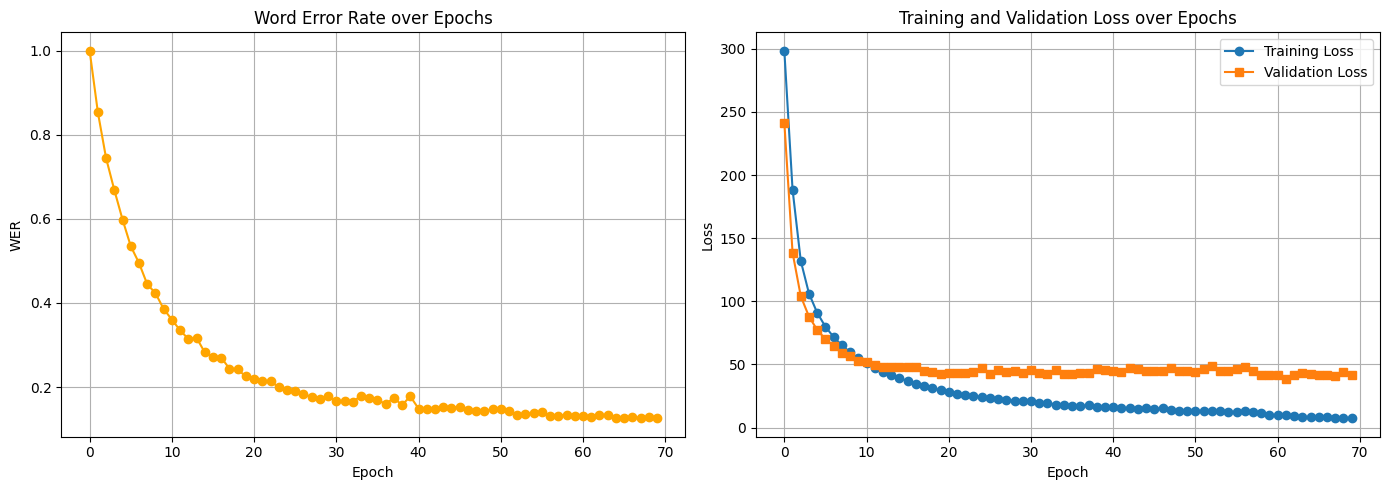

In [42]:
# Plotting
plt.figure(figsize=(14, 5))

# WER Plot
plt.subplot(1, 2, 1)
plt.plot(range(len(history.history['wer'])), history.history['wer'] , marker='o', color='orange')
plt.title('Word Error Rate over Epochs')
plt.xlabel('Epoch')
plt.ylabel('WER')
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(range(len(history.history['wer'])), history.history['loss'], label='Training Loss', marker='o')
plt.plot(range(len(history.history['wer'])), history.history['val_loss'], label='Validation Loss', marker='s')
plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Model Inference

In [43]:
# Let's check results on more validation samples
predictions = []
targets = []

for batch in validation_dataset:
    X, y = batch
    batch_predictions = model.predict(X)
    batch_predictions = decode_batch_predictions(batch_predictions)
    predictions.extend(batch_predictions)

    for label in y:
        label_str = tf.strings.reduce_join(num_to_char(label)).numpy().decode("utf-8")
        targets.append(label_str)

# Calcul du Word Error Rate (WER)
wer_score = wer(targets, predictions)

print("-" * 100)
print(f"Word Error Rate: {wer_score:.4f}")
print("-" * 100)

# Affichage de 5 exemples aléatoires
for i in np.random.randint(0, len(predictions), 5):
    print(f"Target    : {targets[i]}")
    print(f"Prediction: {predictions[i]}")
    print("-" * 100)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 